# Breast Cancer 5-Year Survival — SVM (RBF) with GridSearchCV

This pipeline trains a support vector machine (RBF kernel) for the prediction of the 5-year survival of cancer patients.

In [1]:
# Load the require packages
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    classification_report, matthews_corrcoef,
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
HOLDOUT_COHORTS = {4.0, 5.0}

## 1. Load pre-imputed data and build the 5-year survival label

In [2]:
# Load the data and create labels for 5 year survival
df = pd.read_csv('../data/processed_data/Final_metabric_data_mice_imputed.tsv', sep='\t')
df = df.drop(columns=['Relapse Free Status', 'Relapse Free Status (Months)', "Patient's Vital Status"])

print(f'Raw data shape: {df.shape}')

died_early  = (df['Overall Survival Status'] == '1:DECEASED') & (df['Overall Survival (Months)'] < 60)
survived_5y = df['Overall Survival (Months)'] >= 60
censored    = (df['Overall Survival Status'] == '0:LIVING')  & (df['Overall Survival (Months)'] < 60)

df['label'] = np.nan
df.loc[died_early,  'label'] = 0
df.loc[survived_5y, 'label'] = 1
df = df[~censored].reset_index(drop=True)

print(f'Rows after excluding censored: {len(df)}')
print(df['label'].value_counts().rename({0: 'died <5yr', 1: 'survived 5yr'}))

Raw data shape: (1981, 25)
Rows after excluding censored: 1917
label
survived 5yr    1490
died <5yr        427
Name: count, dtype: int64


## 2. Use Selected Features from Feature Selection Step

In [3]:
DROP_COLS = ['Cohort', 'label', 'Overall Survival Status', 'Overall Survival (Months)']
FEATURES = [c for c in df.columns if c not in DROP_COLS] 

TOP_FEATURES = ['Age at Diagnosis', 'Nottingham prognostic index', 
                'hetloss', 'gain', 'Tumor Size',
                'amp', 'TMB (nonsynonymous)', 'homdel', 
                'Integrative Cluster', 'Pam50 + Claudin-low subtype', 
                'Type of Breast Surgery']
FEATURES = [c for c in df.columns if c in TOP_FEATURES] 

df = df.dropna(subset=['Cohort', 'label']).reset_index(drop=True)

X      = df[FEATURES]
y      = df['label'].astype(int)
groups = df['Cohort']

NUMERIC     = X.select_dtypes(include=np.number).columns.tolist()
CATEGORICAL = [c for c in FEATURES if c not in NUMERIC]

print(f'Rows: {len(df)}')
print(f'Numeric features: {len(NUMERIC)}, Categorical features: {len(CATEGORICAL)}')
print(f'\nLabel distribution: {y.value_counts().to_dict()}')
print(f'Cohorts present: {sorted(groups.unique())}')

Rows: 1917
Numeric features: 8, Categorical features: 3

Label distribution: {1: 1490, 0: 427}
Cohorts present: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


## 3. Split Data

In [4]:
holdout_mask = groups.isin(HOLDOUT_COHORTS)

X_dev,  y_dev,  groups_dev = (X[~holdout_mask].reset_index(drop=True),
                               y[~holdout_mask].reset_index(drop=True),
                               groups[~holdout_mask].reset_index(drop=True))
X_hold, y_hold             = (X[holdout_mask].reset_index(drop=True),
                               y[holdout_mask].reset_index(drop=True))

print(f'Dev pool : {len(X_dev)} rows, cohorts {sorted(groups_dev.unique())}')
print(f'Holdout  : {len(X_hold)} rows, cohorts {sorted(groups[holdout_mask].unique())} — sealed until Section 7')

Dev pool : 1518 rows, cohorts [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
Holdout  : 399 rows, cohorts [np.float64(4.0), np.float64(5.0)] — sealed until Section 7


## 4. Pipeline and Parameter Grid

In [5]:
def make_preprocessor():
    return ColumnTransformer([
        ('num', StandardScaler(), NUMERIC),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ])

BASE_PIPES = {
    'svm_rbf': Pipeline([
        ('prep',  make_preprocessor()),
        ('model', SVC(
            kernel='rbf',
            class_weight='balanced',
            probability=True,          # needed for ROC-AUC / PR-AUC
            random_state=RANDOM_STATE,
        )),
    ]),
}

PARAM_GRIDS = {
    'svm_rbf': {
        'model__C':     [0.01, 0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    },
}

## 5. GridSearchCV — Leave-One-Cohort-Out (On Cohorts 1, 2, 3)

In [6]:
gkf = GroupKFold(n_splits=groups_dev.nunique())  # 3 folds

gs_objects      = {}
best_estimators = {}

for model_name, pipe in BASE_PIPES.items():
    print(f'\nRunning GridSearchCV for {model_name}...')
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=PARAM_GRIDS[model_name],
        cv=gkf,
        scoring='roc_auc',
        refit=True,         # refit best params on entire dev pool
        n_jobs=-1,
        verbose=1,
    )
    gs.fit(X_dev, y_dev, groups=groups_dev)

    gs_objects[model_name] = gs
    best_estimators[model_name] = gs.best_estimator_

    print(f'Best params: {gs.best_params_}')
    print(f'Best CV ROC-AUC: {gs.best_score_:.4f}')


Running GridSearchCV for svm_rbf...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'model__C': 1, 'model__gamma': 0.01}
Best CV ROC-AUC: 0.7547


## 6. Full Cross-Validation Results Table

In [7]:
for model_name, gs in gs_objects.items():
    results   = pd.DataFrame(gs.cv_results_)
    param_cols = [c for c in results.columns if c.startswith('param_')]
    display_cols = param_cols + ['mean_test_score', 'std_test_score', 'rank_test_score']
    top5 = (results[display_cols]
            .sort_values('rank_test_score')
            .head(5)
            .reset_index(drop=True))
    top5.columns = [c.replace('param_model__', '') for c in top5.columns]
    print(f'\n{model_name} — top 5 by CV ROC-AUC\n')
    print(top5.round(4).to_string(index=False))


svm_rbf — top 5 by CV ROC-AUC

    C  gamma  mean_test_score  std_test_score  rank_test_score
  1.0   0.01           0.7547          0.0351                1
  1.0   auto           0.7534          0.0314                2
 10.0  0.001           0.7500          0.0343                3
100.0  0.001           0.7494          0.0376                4
 10.0   0.01           0.7493          0.0349                5


## 7. Final Evaluation on the Holdout (cohorts 4 & 5)

In [8]:
ROC_DIR = '../results/roc_data'
os.makedirs(ROC_DIR, exist_ok=True)

for model_name, pipe in best_estimators.items():
    proba = pipe.predict_proba(X_hold)[:, 1]
    preds = pipe.predict(X_hold)

    print(f'\n=== {model_name} — holdout (cohorts 4, 5) ===')
    print(f'  Best params : {gs_objects[model_name].best_params_}')
    print(f'  ROC-AUC : {roc_auc_score(y_hold, proba):.3f}')
    print(f'  PR-AUC  : {average_precision_score(y_hold, proba):.3f}')
    print(f'  MCC     : {matthews_corrcoef(y_hold, preds):.3f}')
    print(classification_report(y_hold, preds, target_names=['died_<5y', 'survived_5y']))

    # Save holdout probabilities (for cross-model ROC/PR comparison)
    proba_payload = {
        'model_name':  model_name,
        'y_true':      y_hold.to_numpy(),
        'y_score':     proba,
        'y_pred':      preds,
        'best_params': gs_objects[model_name].best_params_,
    }
    proba_path = os.path.join(ROC_DIR, f'roc_{model_name}.joblib')
    joblib.dump(proba_payload, proba_path)
    print(f'  Saved probabilities -> {proba_path}')


=== svm_rbf — holdout (cohorts 4, 5) ===
  Best params : {'model__C': 1, 'model__gamma': 0.01}
  ROC-AUC : 0.769
  PR-AUC  : 0.905
  MCC     : 0.346
              precision    recall  f1-score   support

    died_<5y       0.39      0.80      0.52        94
 survived_5y       0.91      0.61      0.73       305

    accuracy                           0.65       399
   macro avg       0.65      0.70      0.63       399
weighted avg       0.78      0.65      0.68       399

  Saved probabilities -> ../results/roc_data/roc_svm_rbf.joblib


## 8. ROC and Precision-Recall curves — holdout

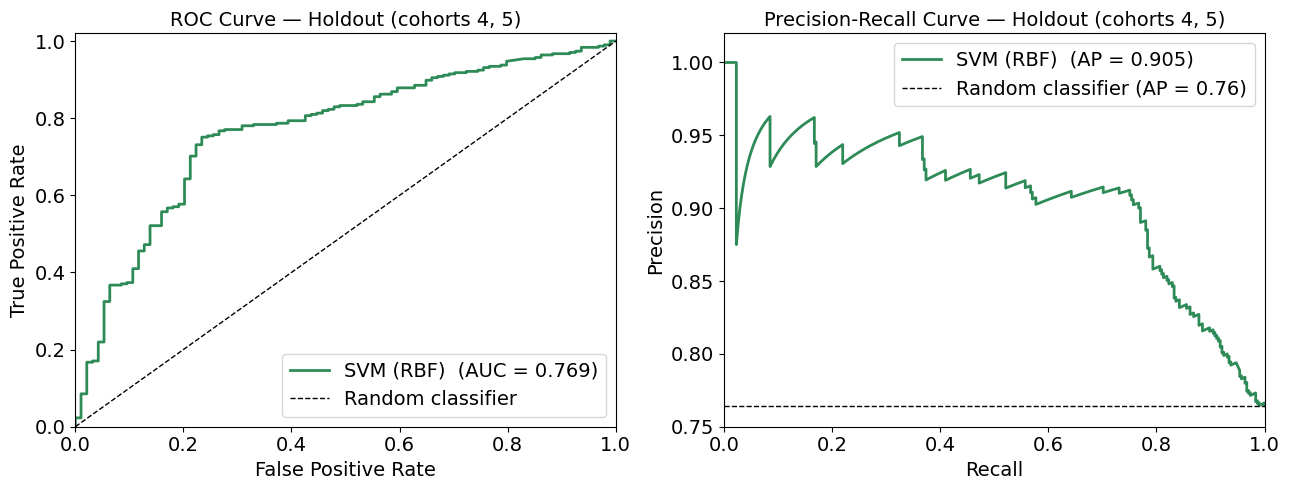

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

colors = {'svm_rbf': 'seagreen'}
labels_map = {'svm_rbf': 'SVM (RBF)'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC ---
ax = axes[0]
for model_name, pipe in best_estimators.items():
    proba = pipe.predict_proba(X_hold)[:, 1]
    fpr, tpr, _ = roc_curve(y_hold, proba)
    auc = roc_auc_score(y_hold, proba)
    ax.plot(fpr, tpr, color=colors[model_name], lw=2,
            label=f'{labels_map[model_name]}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_title('ROC Curve — Holdout (cohorts 4, 5)', fontsize=14)
ax.legend(fontsize=14)
ax.tick_params(which='both', labelsize=14)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# --- PR ---
ax = axes[1]
baseline = y_hold.mean()
for model_name, pipe in best_estimators.items():
    proba = pipe.predict_proba(X_hold)[:, 1]
    prec, rec, _ = precision_recall_curve(y_hold, proba)
    ap = average_precision_score(y_hold, proba)
    ax.plot(rec, prec, color=colors[model_name], lw=2,
            label=f'{labels_map[model_name]}  (AP = {ap:.3f})')

ax.axhline(baseline, color='k', lw=1, linestyle='--',
           label=f'Random classifier (AP = {baseline:.2f})')
ax.set_xlabel('Recall', fontsize=14)
ax.set_ylabel('Precision', fontsize=14)
ax.set_title('Precision-Recall Curve — Holdout (cohorts 4, 5)', fontsize=14)
ax.legend(fontsize=14)
ax.set_xlim([0, 1])
ax.set_ylim([0.75, 1.02])
ax.tick_params(which='both', labelsize=14)
plt.tight_layout()
plt.show()